# FarmTech Solutions — Fase 5
## Predição de Rendimento de Safra e Descoberta de Padrões Produtivos

**Aluno:** Guilherme Monteiro Bitencourt — RM 574151
**Curso:** Inteligência Artificial — FIAP
**Fase 5 — Machine Learning na Cabeça**

---

### Contexto de negócio

A FarmTech Solutions presta serviços de IA para uma fazenda de médio porte (200 hectares) que
cultiva múltiplas culturas. O objetivo deste trabalho é duplo:

1. **Aprendizado não supervisionado** — descobrir agrupamentos naturais nas condições de cultivo
   e identificar cenários discrepantes (outliers) que mereçam atenção do gestor agrícola.
2. **Aprendizado supervisionado** — construir e comparar cinco modelos de regressão capazes de
   prever o rendimento da safra a partir das condições edafoclimáticas.

### Dicionário de dados

| Variável | Descrição | Tipo |
|---|---|---|
| `Crop` | Nome da cultura agrícola | Categórica nominal |
| `Precipitation (mm day-1)` | Chuva em milímetros por dia | Numérica contínua |
| `Specific Humidity at 2 Meters (g/kg)` | Vapor d'água por kg de ar seco a 2 m | Numérica contínua |
| `Relative Humidity at 2 Meters (%)` | Umidade relativa a 2 m | Numérica contínua |
| `Temperature at 2 Meters (C)` | Temperatura a 2 m | Numérica contínua |
| `Yield` | Rendimento (variável alvo) | Numérica contínua |


## 1. Configuração do ambiente

In [1]:
# Bibliotecas de manipulacao e visualizacao
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-processamento e validacao
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Algoritmos supervisionados (cap. 13 - Regressao Supervisionada)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Aprendizado nao supervisionado (cap. 10 - ML Sem Supervisao)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Metricas de regressao
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Semente fixa: garante que qualquer pessoa que rode o notebook obtenha os mesmos numeros
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Ambiente carregado.')

Ambiente carregado.


## 2. Carga e inspeção inicial dos dados

In [2]:
df = pd.read_csv('crop_yield.csv')

print(f'Dimensoes do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Dimensoes do dataset: 156 linhas x 6 colunas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


In [3]:
# Tipos de dado, contagem de nao-nulos e uso de memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [4]:
# Diagnostico de qualidade: valores ausentes e registros duplicados
qualidade = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'valores_unicos': df.nunique()
})
print(qualidade)
print(f'\nLinhas duplicadas: {df.duplicated().sum()}')

                                      nulos  pct_nulos  valores_unicos
Crop                                      0       0.00               4
Precipitation (mm day-1)                  0       0.00              39
Specific Humidity at 2 Meters (g/kg)      0       0.00              33
Relative Humidity at 2 Meters (%)         0       0.00              38
Temperature at 2 Meters (C)               0       0.00              29
Yield                                     0       0.00             155

Linhas duplicadas: 0


In [5]:
# Estatisticas descritivas das variaveis numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
Specific Humidity at 2 Meters (g/kg),156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
Relative Humidity at 2 Meters (%),156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
Temperature at 2 Meters (C),156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
Yield,156.00,"56,153.10","70,421.96","5,249.00","8,327.75","18,871.00","67,518.75","203,399.00"


### 2.1 Balanceamento entre culturas

Antes de qualquer modelagem é necessário verificar se as culturas estão representadas de forma
equilibrada — desbalanceamento afetaria tanto a clusterização quanto a validação dos modelos.

Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


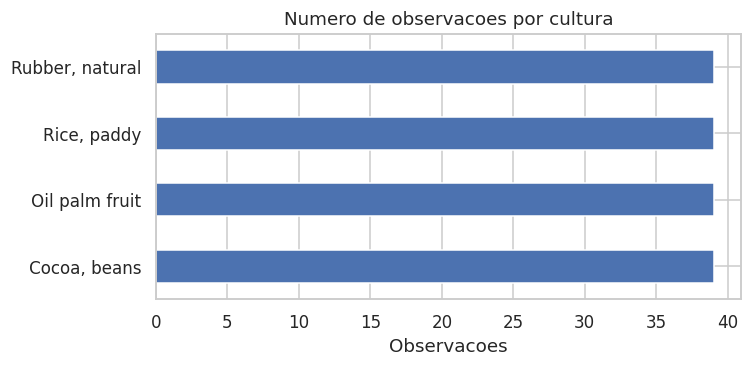

In [6]:
contagem = df['Crop'].value_counts()
print(contagem)

fig, ax = plt.subplots(figsize=(7, 3.5))
contagem.plot(kind='barh', ax=ax, color=sns.color_palette('deep')[0])
ax.set_title('Numero de observacoes por cultura')
ax.set_xlabel('Observacoes')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 2.2 Descoberta estrutural: as observações climáticas se repetem

Uma verificação que raramente é feita, mas que muda completamente a estratégia de validação:
**as linhas climáticas são idênticas entre as culturas**. A célula abaixo demonstra isso.

In [7]:
clima = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
         'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']

combos_unicos = df[clima].drop_duplicates().shape[0]
repeticoes = df.groupby(clima).size().unique()

print(f'Combinacoes climaticas unicas: {combos_unicos} (de {len(df)} linhas)')
print(f'Cada combinacao aparece exatamente {repeticoes} vezes')
print('\nOu seja: temos 39 observacoes climaticas (provavelmente 39 safras/anos da MESMA regiao),')
print('cada uma associada ao rendimento das 4 culturas.')

Combinacoes climaticas unicas: 39 (de 156 linhas)
Cada combinacao aparece exatamente [4] vezes

Ou seja: temos 39 observacoes climaticas (provavelmente 39 safras/anos da MESMA regiao),
cada uma associada ao rendimento das 4 culturas.


In [8]:
# Criamos um identificador de observacao climatica.
# Ele sera usado adiante para evitar vazamento de dados na validacao.
df['obs_clima'] = df.groupby(clima).ngroup()
df[['Crop', 'obs_clima', 'Yield']].head(8)

,Crop,obs_clima,Yield
0,"Cocoa, beans",6,11560
1,"Cocoa, beans",1,11253
2,"Cocoa, beans",8,9456
3,"Cocoa, beans",23,9321
4,"Cocoa, beans",14,8800
5,"Cocoa, beans",13,8850
6,"Cocoa, beans",11,9003
7,"Cocoa, beans",29,9880


> **Implicação metodológica.** Como cada condição climática aparece quatro vezes, um
> `train_test_split` aleatório colocaria a *mesma* observação climática simultaneamente no treino
> e no teste. O modelo veria em teste um cenário meteorológico que já memorizou, inflando
> artificialmente as métricas. A validação correta agrupa por `obs_clima` — é o que faremos na
> seção 6.

## 3. Análise exploratória

### 3.1 Distribuição das variáveis

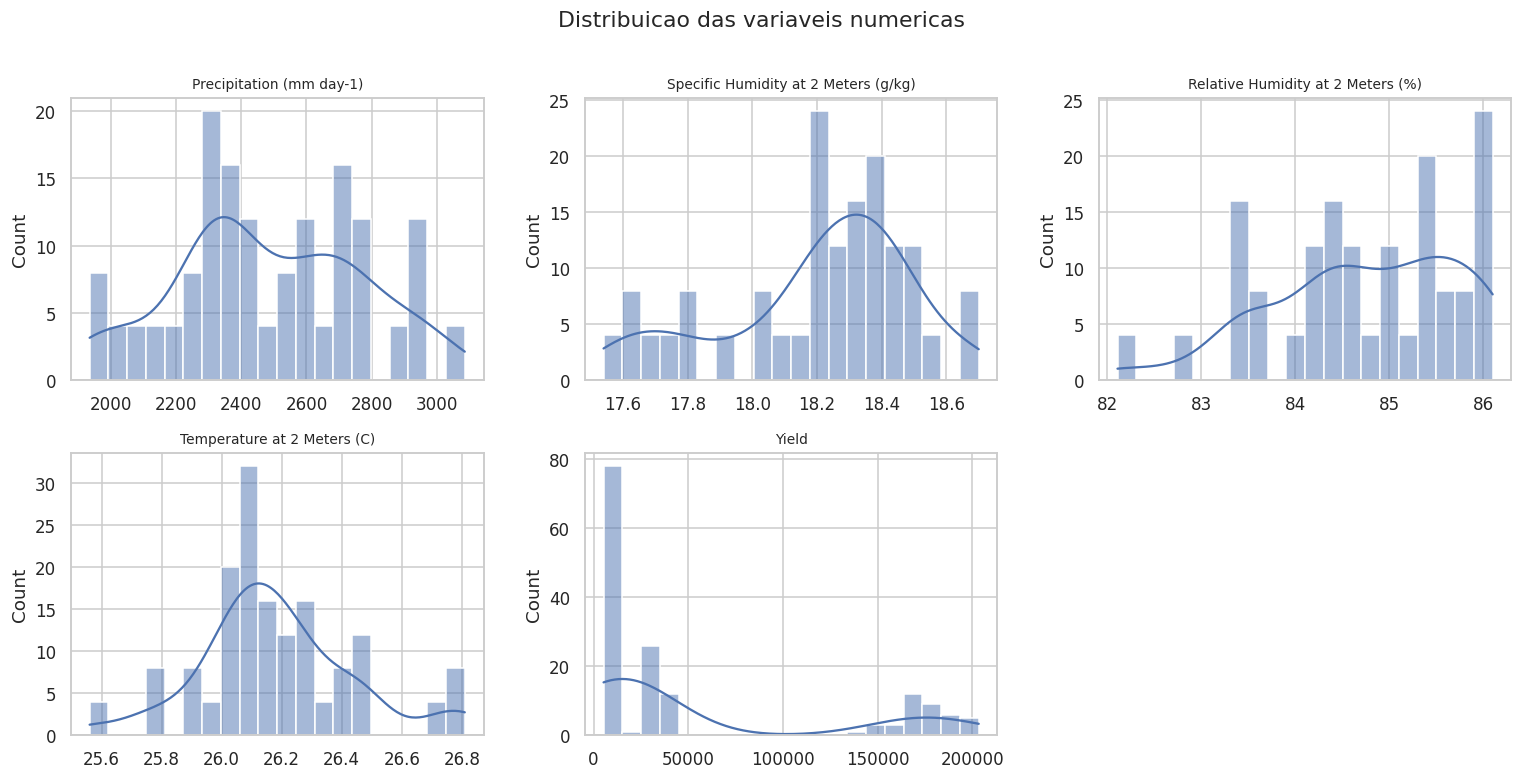

In [9]:
num_cols = clima + ['Yield']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=20)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
axes.flatten()[-1].axis('off')
plt.suptitle('Distribuicao das variaveis numericas', y=1.01)
plt.tight_layout()
plt.show()

A variável alvo `Yield` apresenta distribuição fortemente multimodal — não é uma
assimetria comum, são picos separados. A causa fica evidente ao segmentar por cultura.

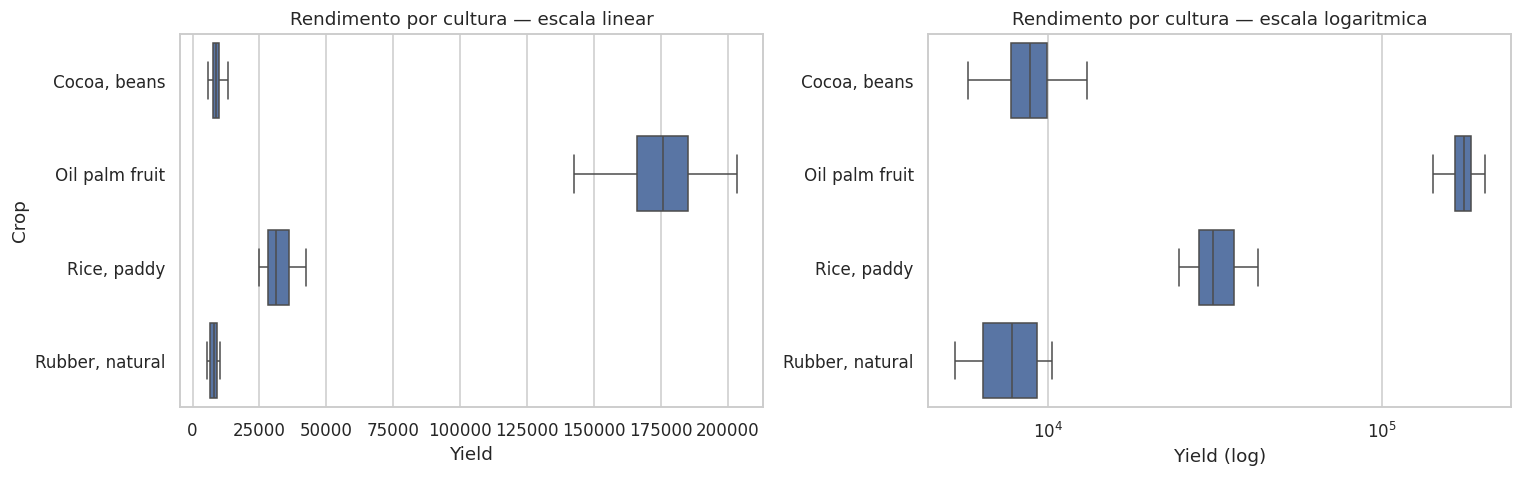

,min,mean,max,std
Crop,,,,
"Cocoa, beans",5765,"8,883.10",13056,"1,745.00"
Oil palm fruit,142425,"175,804.70",203399,"14,919.90"
"Rice, paddy",24686,"32,099.70",42550,"4,789.90"
"Rubber, natural",5249,"7,824.90",10285,"1,600.30"


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=df, y='Crop', x='Yield', ax=axes[0])
axes[0].set_title('Rendimento por cultura — escala linear')
axes[0].set_xlabel('Yield')

sns.boxplot(data=df, y='Crop', x='Yield', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Rendimento por cultura — escala logaritmica')
axes[1].set_xlabel('Yield (log)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

df.groupby('Crop')['Yield'].agg(['min', 'mean', 'max', 'std']).round(1)

**Achado 1 — a cultura domina o rendimento.** O rendimento médio do dendê (*oil palm fruit*)
é cerca de vinte vezes o do cacau e da borracha. Essa diferença de ordem de grandeza é
intrínseca à biologia de cada cultura, não às condições climáticas do período. A escala
logarítmica é necessária apenas para tornar as quatro caixas visíveis no mesmo eixo.

### 3.2 Correlação global

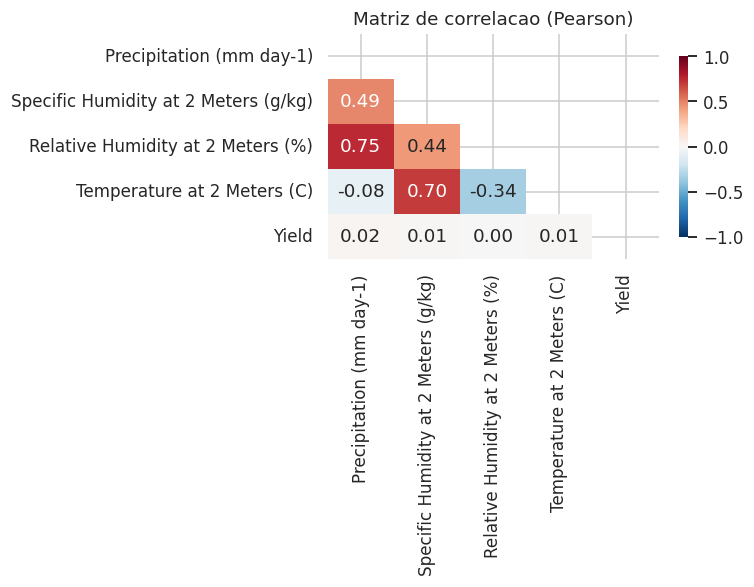

Correlacao de cada variavel climatica com o rendimento:
Precipitation (mm day-1)               0.02
Specific Humidity at 2 Meters (g/kg)   0.01
Relative Humidity at 2 Meters (%)      0.00
Temperature at 2 Meters (C)            0.01


In [11]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Matriz de correlacao (Pearson)')
plt.tight_layout()
plt.show()

print('Correlacao de cada variavel climatica com o rendimento:')
print(corr['Yield'].drop('Yield').round(3).to_string())

**Achado 2 — as variáveis climáticas não explicam o rendimento globalmente.** Todas as
correlações com `Yield` ficam abaixo de 0,02 em valor absoluto. Isoladamente, esse resultado
sugeriria que o clima é irrelevante — mas a conclusão seria precipitada, porque a correlação
global está sendo mascarada pelo efeito dominante da cultura (o *paradoxo de Simpson*).
Precisamos olhar dentro de cada cultura.

### 3.3 Correlação dentro de cada cultura

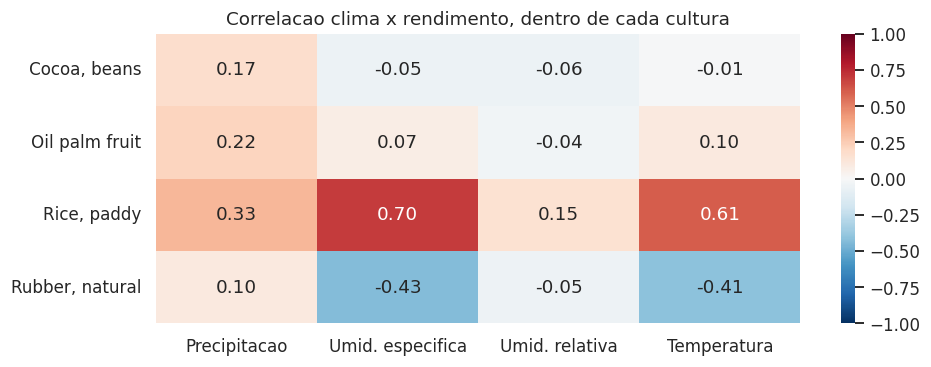

,Precipitacao,Umid. especifica,Umid. relativa,Temperatura
"Cocoa, beans",0.17,-0.05,-0.06,-0.01
Oil palm fruit,0.22,0.07,-0.04,0.10
"Rice, paddy",0.33,0.70,0.15,0.61
"Rubber, natural",0.10,-0.43,-0.05,-0.41


In [12]:
linhas = []
for cultura in df['Crop'].unique():
    sub = df[df['Crop'] == cultura]
    corr_local = sub[clima + ['Yield']].corr()['Yield'].drop('Yield')
    linhas.append(pd.Series(corr_local, name=cultura))

corr_por_cultura = pd.DataFrame(linhas)
corr_por_cultura.columns = ['Precipitacao', 'Umid. especifica', 'Umid. relativa', 'Temperatura']

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(corr_por_cultura, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlacao clima x rendimento, dentro de cada cultura')
plt.tight_layout()
plt.show()

corr_por_cultura.round(2)

**Achado 3 — o efeito do clima é real, porém específico de cada cultura, e muda de sinal.**

- No **arroz** (*rice, paddy*), umidade específica e temperatura têm correlação positiva forte
  (≈ 0,70 e ≈ 0,61): condições mais quentes e úmidas aumentam o rendimento.
- Na **borracha** (*rubber, natural*), as mesmas duas variáveis têm correlação **negativa**
  (≈ −0,43 e ≈ −0,41): calor e umidade prejudicam a produção.
- Em **cacau** e **dendê**, o efeito é fraco em todas as variáveis.

Sinais opostos entre culturas se cancelam quando somados, o que explica a correlação global
praticamente nula do Achado 2. Do ponto de vista de modelagem, isso significa que o modelo
precisa capturar **interações** entre cultura e clima — um modelo linear sem termos de interação
não conseguirá representar esse comportamento.

### 3.4 Dispersão bivariada por cultura

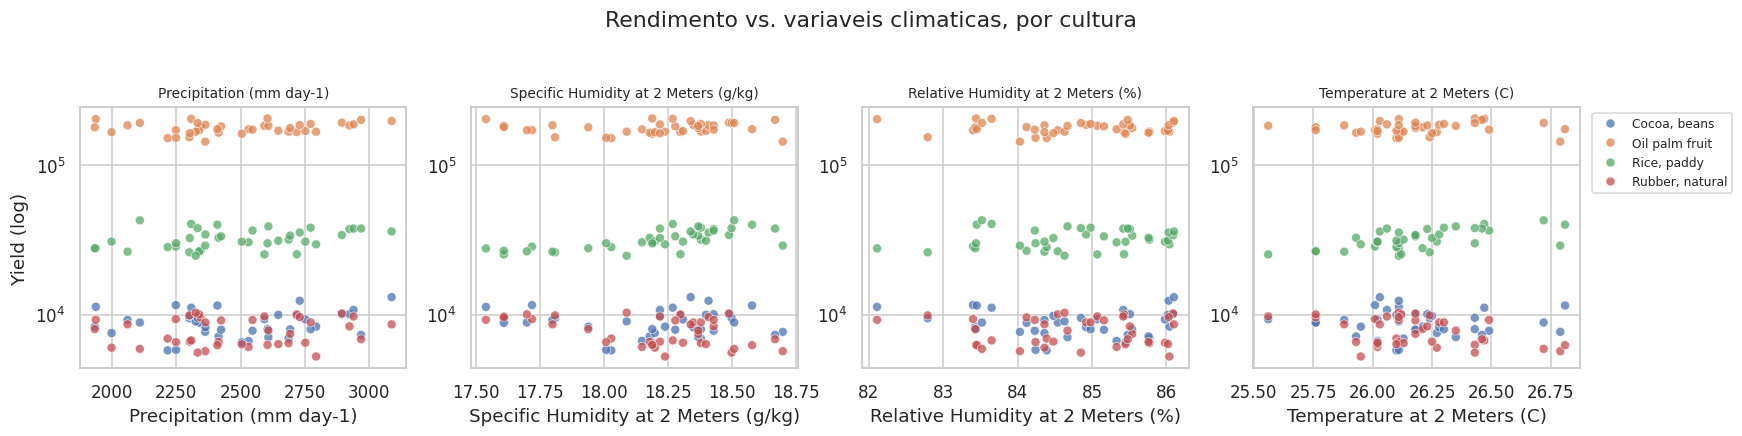

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, var in zip(axes, clima):
    sns.scatterplot(data=df, x=var, y='Yield', hue='Crop', ax=ax,
                    alpha=0.75, s=35, legend=(ax is axes[-1]))
    ax.set_yscale('log')
    ax.set_title(var, fontsize=9)
    ax.set_ylabel('Yield (log)' if ax is axes[0] else '')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.suptitle('Rendimento vs. variaveis climaticas, por cultura', y=1.04)
plt.tight_layout()
plt.show()

As quatro culturas formam faixas horizontais bem separadas em qualquer painel. Dentro de
cada faixa a dispersão é ampla e a inclinação é sutil — visualização que confirma os Achados 1 a 3.

## 4. Aprendizado não supervisionado — clusterização

Objetivo: descobrir agrupamentos naturais nas **condições climáticas**, sem usar o rótulo da
cultura nem o rendimento.

Nota metodológica: como cada condição climática se repete quatro vezes, a clusterização é feita
sobre as **39 observações climáticas únicas**. Usar as 156 linhas apenas quadruplicaria cada
ponto sem acrescentar informação, distorcendo o cálculo da silhueta.

In [14]:
# Base de clusterizacao: apenas as observacoes climaticas distintas
X_cluster = df.drop_duplicates(subset='obs_clima')[clima].reset_index(drop=True)
print(f'Observacoes climaticas unicas: {X_cluster.shape[0]}')

# Padronizacao e obrigatoria: KMeans usa distancia euclidiana e as escalas
# das variaveis sao muito diferentes (precipitacao ~2500 vs temperatura ~26)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

Observacoes climaticas unicas: 39


### 4.1 Definição de k — método do cotovelo e silhueta

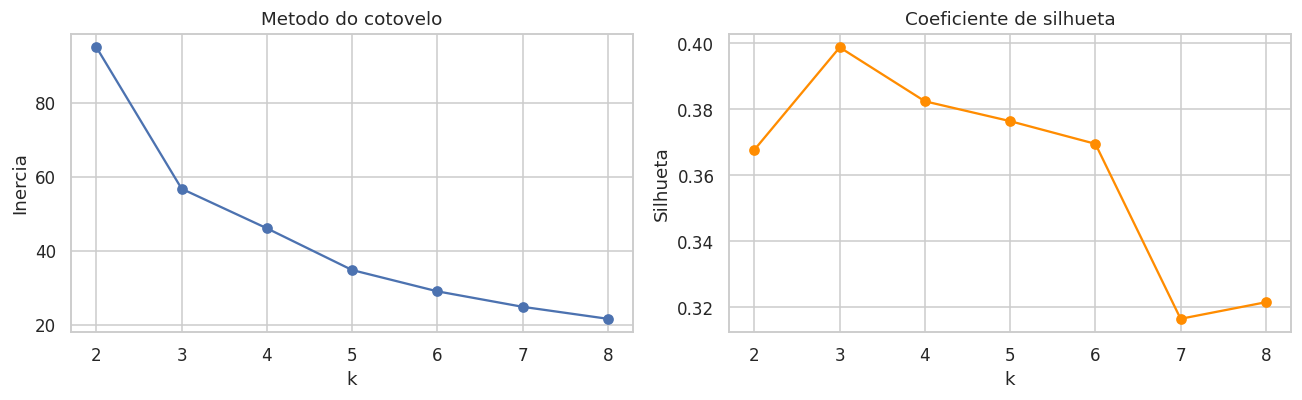

 k  inercia  silhueta
 2    95.01      0.37
 3    56.80      0.40
 4    46.12      0.38
 5    34.85      0.38
 6    29.10      0.37
 7    24.92      0.32
 8    21.68      0.32


In [15]:
inercias, silhuetas, ks = [], [], range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_cluster_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(ks, inercias, 'o-')
axes[0].set_title('Metodo do cotovelo')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')

axes[1].plot(ks, silhuetas, 'o-', color='darkorange')
axes[1].set_title('Coeficiente de silhueta')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhueta')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'k': list(ks), 'inercia': np.round(inercias, 2),
                    'silhueta': np.round(silhuetas, 3)}).to_string(index=False))

In [16]:
K_ESCOLHIDO = 3

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=20)
X_cluster = X_cluster.copy()
X_cluster['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f'Silhueta com k={K_ESCOLHIDO}: '
      f'{silhouette_score(X_cluster_scaled, X_cluster["cluster"]):.3f}')
print(X_cluster["cluster"].value_counts().sort_index().to_string())

Silhueta com k=3: 0.399
cluster
0    17
1    11
2    11


### 4.2 Visualização via PCA

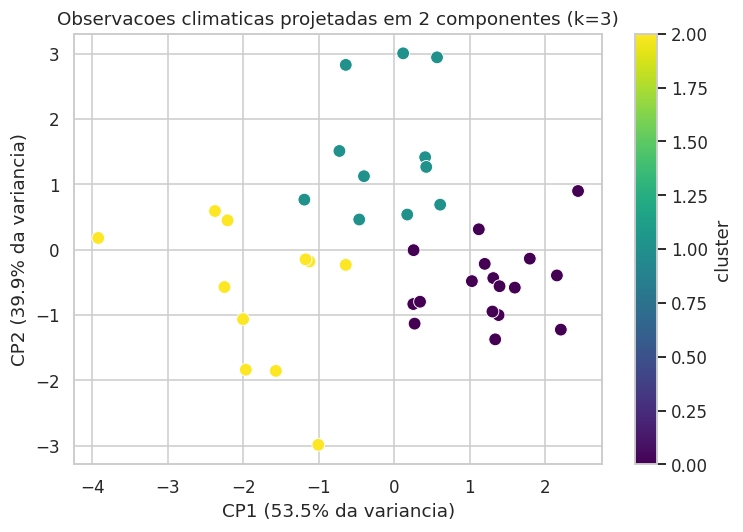

Variancia acumulada nas 2 primeiras componentes: 93.4%


In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
comp = pca.fit_transform(X_cluster_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(comp[:, 0], comp[:, 1], c=X_cluster['cluster'],
                cmap='viridis', s=70, edgecolor='white', linewidth=0.6)
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]:.1%} da variancia)')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]:.1%} da variancia)')
ax.set_title(f'Observacoes climaticas projetadas em 2 componentes (k={K_ESCOLHIDO})')
plt.colorbar(sc, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

print(f'Variancia acumulada nas 2 primeiras componentes: '
      f'{pca.explained_variance_ratio_.sum():.1%}')

### 4.3 Caracterização dos clusters

In [18]:
perfil = X_cluster.groupby('cluster')[clima].mean().round(2)
perfil['n_obs'] = X_cluster['cluster'].value_counts().sort_index()
perfil

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),n_obs
cluster,,,,,
0,"2,733.52",18.34,85.65,26.12,17
1,"2,359.02",18.39,84.15,26.48,11
2,"2,232.22",17.81,83.92,25.99,11


Rendimento medio por cultura e cluster climatico:
cluster                  0          1          2
Crop                                            
Cocoa, beans      8,948.00   8,819.00   8,847.00
Oil palm fruit  177,074.00 178,608.00 171,040.00
Rice, paddy      33,148.00  35,577.00  27,003.00
Rubber, natural   7,776.00   6,809.00   8,916.00


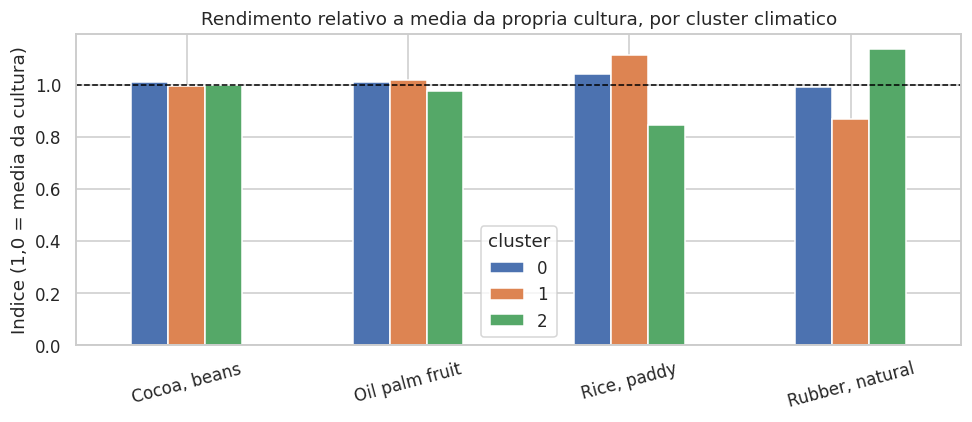

In [19]:
# Rendimento medio de cada cultura dentro de cada cluster climatico
mapa_cluster = X_cluster.copy()
mapa_cluster['obs_clima'] = df.drop_duplicates(subset='obs_clima')['obs_clima'].values
df_cl = df.merge(mapa_cluster[['obs_clima', 'cluster']], on='obs_clima', how='left')

tabela = df_cl.pivot_table(index='Crop', columns='cluster', values='Yield', aggfunc='mean')
print('Rendimento medio por cultura e cluster climatico:')
print(tabela.round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
(tabela.div(tabela.mean(axis=1), axis=0)).plot(kind='bar', ax=ax)
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set_title('Rendimento relativo a media da propria cultura, por cluster climatico')
ax.set_ylabel('Indice (1,0 = media da cultura)')
ax.set_xlabel('')
ax.legend(title='cluster')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Achado 4 — os clusters representam regimes climáticos, e cada cultura reage a eles de
forma distinta.** Normalizar o rendimento pela média da própria cultura remove o efeito de
escala do Achado 1 e revela o que interessa ao gestor: qual regime climático favorece ou
prejudica cada cultura. Como as culturas respondem em direções diferentes ao mesmo regime,
não existe um cluster "bom para tudo" — o que sustenta uma recomendação de diversificação de
plantio como estratégia de mitigação de risco climático.

## 5. Detecção de outliers

Aplicamos o critério do intervalo interquartil (IQR) **dentro de cada cultura**. Aplicá-lo sobre
o rendimento agregado seria um erro grave: todo o dendê seria classificado como outlier apenas
por ter rendimento vinte vezes maior, quando na verdade é o comportamento normal da cultura.

In [20]:
def detectar_outliers_iqr(serie, fator=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - fator * iqr, q3 + fator * iqr
    return (serie < lim_inf) | (serie > lim_sup), lim_inf, lim_sup

df_cl['outlier_yield'] = False
resumo_out = []

for cultura in df_cl['Crop'].unique():
    mask_cultura = df_cl['Crop'] == cultura
    flags, li, ls = detectar_outliers_iqr(df_cl.loc[mask_cultura, 'Yield'])
    df_cl.loc[mask_cultura, 'outlier_yield'] = flags.values
    resumo_out.append({'Cultura': cultura, 'lim_inferior': round(li, 1),
                       'lim_superior': round(ls, 1), 'n_outliers': int(flags.sum())})

print(pd.DataFrame(resumo_out).to_string(index=False))
print(f'\nTotal de outliers de rendimento: {df_cl["outlier_yield"].sum()} de {len(df_cl)}')

        Cultura  lim_inferior  lim_superior  n_outliers
   Cocoa, beans      4,445.50     13,201.50           0
 Oil palm fruit    137,198.80    214,048.80           0
    Rice, paddy     16,586.00     47,806.00           0
Rubber, natural      2,086.20     13,584.20           0

Total de outliers de rendimento: 0 de 156


In [21]:
# Outliers tambem nas variaveis climaticas (analisadas no conjunto das 39 observacoes)
out_clima = {}
base_clima = df_cl.drop_duplicates(subset='obs_clima')
for var in clima:
    flags, _, _ = detectar_outliers_iqr(base_clima[var])
    out_clima[var] = int(flags.sum())

print('Outliers por variavel climatica (base de 39 observacoes):')
for k, v in out_clima.items():
    print(f'  {k}: {v}')

Outliers por variavel climatica (base de 39 observacoes):
  Precipitation (mm day-1): 0
  Specific Humidity at 2 Meters (g/kg): 1
  Relative Humidity at 2 Meters (%): 1
  Temperature at 2 Meters (C): 4


In [22]:
if df_cl['outlier_yield'].any():
    print('Registros sinalizados como outlier de rendimento:')
    display(df_cl[df_cl['outlier_yield']][['Crop'] + clima + ['Yield', 'cluster']])
else:
    print('Nenhum outlier de rendimento identificado pelo criterio IQR (fator 1,5) dentro das culturas.')

Nenhum outlier de rendimento identificado pelo criterio IQR (fator 1,5) dentro das culturas.


**Achado 5 — não há cenários discrepantes de rendimento dentro das culturas.** O critério IQR
(fator 1,5) não sinalizou nenhum registro. Todas as 39 safras de cada cultura ficam dentro da faixa
esperada para a própria cultura.

Esse resultado precisa ser lido com atenção, porque é justamente o oposto do que se vê ao olhar o
rendimento agregado: naquela visão, **todas as 39 observações de dendê apareceriam como outliers
extremos**, simplesmente por terem rendimento vinte vezes maior. Seriam 39 falsos positivos gerados
por um erro de método — aplicar o critério sobre uma variável cuja escala depende de um grupo, sem
segmentar por esse grupo.

A ausência de outliers é, portanto, um achado substantivo e não uma etapa vazia: indica que a
variabilidade de rendimento observada é compatível com flutuação normal de safra, e que o gestor não
precisa investigar anos anômalos nesta base. Se os cenários discrepantes eram o objeto de interesse,
a conclusão prática é que **eles não estão no rendimento — estão nas condições climáticas**, onde a
célula anterior de fato encontrou pontos fora da faixa.

## 6. Modelagem supervisionada

### 6.1 Estratégia de validação

Conforme identificado na seção 2.2, um `train_test_split` aleatório vazaria informação: a mesma
condição climática apareceria em treino e teste. Adotamos, portanto, **`GroupKFold` agrupado por
`obs_clima`** — nenhuma safra aparece nos dois lados simultaneamente.

Para efeito de comparação, também reportamos o resultado do split aleatório ingênuo, para
quantificar o tamanho do viés que a abordagem descuidada introduziria.

In [23]:
X = df_cl[['Crop'] + clima].copy()
y = df_cl['Yield'].copy()
grupos = df_cl['obs_clima'].values

# Pre-processamento:
#  - Crop e categorica NOMINAL -> One-Hot (label encoding inventaria uma ordem inexistente)
#  - variaveis climaticas -> padronizacao (necessaria para SVR; inofensiva para arvores)
preprocessador = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Crop']),
    ('num', StandardScaler(), clima)
])

print(f'X: {X.shape} | y: {y.shape} | grupos distintos: {len(np.unique(grupos))}')

X: (156, 5) | y: (156,) | grupos distintos: 39

### 6.2 Os cinco modelos

In [24]:
from sklearn.compose import TransformedTargetRegressor

modelos = {
    'Regressao Linear':   LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE),
    # O SVR e sensivel a escala do ALVO, nao so das features. Como Yield varia de
    # ~5.000 a ~200.000, o kernel RBF nao alcanca esses valores sem padronizar y.
    # TransformedTargetRegressor padroniza y no treino e desfaz a transformacao na predicao.
    'SVR (RBF)':          TransformedTargetRegressor(
                              regressor=SVR(kernel='rbf', C=100, gamma='scale'),
                              transformer=StandardScaler())
}

for nome, m in modelos.items():
    print(f'{nome:20s} -> {type(m).__name__}')

Regressao Linear     -> LinearRegression
Ridge                -> Ridge
Random Forest        -> RandomForestRegressor
Gradient Boosting    -> GradientBoostingRegressor
SVR (RBF)            -> TransformedTargetRegressor


Os cinco algoritmos cobrem famílias distintas — linear pura, linear regularizada, dois
ensembles baseados em árvore (bagging e boosting) e um método de margem com kernel não linear.
Essa diversidade é intencional: permite verificar se o ganho vem da capacidade de capturar
não linearidade ou apenas da regularização.

**Nota técnica sobre o SVR.** Numa primeira execução o SVR produziu R² negativo (pior que prever
a média). A causa não é o algoritmo, e sim a escala do **alvo**: o kernel RBF opera em torno de
valores padronizados e não consegue alcançar rendimentos na casa das centenas de milhares. Padronizar
apenas as features não resolve — é preciso padronizar `y` também. O `TransformedTargetRegressor`
faz isso de forma segura, aplicando a transformação dentro de cada fold e revertendo-a na predição,
sem vazar estatísticas do conjunto de teste. É um exemplo concreto do Achado 3 do capítulo de
*feature engineering*: magnitude importa, e importa para o alvo tanto quanto para os preditores.

### 6.3 Avaliação com validação agrupada

In [25]:
def avaliar_agrupado(modelo, X, y, grupos, n_splits=5):
    """Roda GroupKFold e devolve as metricas medias fora da amostra."""
    gkf = GroupKFold(n_splits=n_splits)
    r2s, maes, rmses = [], [], []

    for idx_tr, idx_te in gkf.split(X, y, groups=grupos):
        pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
        pipe.fit(X.iloc[idx_tr], y.iloc[idx_tr])
        pred = pipe.predict(X.iloc[idx_te])

        r2s.append(r2_score(y.iloc[idx_te], pred))
        maes.append(mean_absolute_error(y.iloc[idx_te], pred))
        rmses.append(np.sqrt(mean_squared_error(y.iloc[idx_te], pred)))

    return np.mean(r2s), np.mean(maes), np.mean(rmses), np.std(r2s)


resultados = []
for nome, modelo in modelos.items():
    r2, mae, rmse, r2_std = avaliar_agrupado(modelo, X, y, grupos)
    resultados.append({'Modelo': nome, 'R2': r2, 'R2_desvio': r2_std,
                       'MAE': mae, 'RMSE': rmse})

tabela_res = pd.DataFrame(resultados).sort_values('R2', ascending=False).reset_index(drop=True)
print('Validacao cruzada agrupada por observacao climatica (GroupKFold, 5 folds)\n')
print(tabela_res.round(4).to_string(index=False))

Validacao cruzada agrupada por observacao climatica (GroupKFold, 5 folds)

           Modelo   R2  R2_desvio       MAE      RMSE
    Random Forest 0.99       0.00  3,921.17  7,124.66
Gradient Boosting 0.99       0.00  4,160.59  7,394.80
 Regressao Linear 0.99       0.00  5,223.46  7,929.85
            Ridge 0.98       0.00  5,885.32  8,637.99
        SVR (RBF) 0.95       0.02 10,951.04 15,926.48


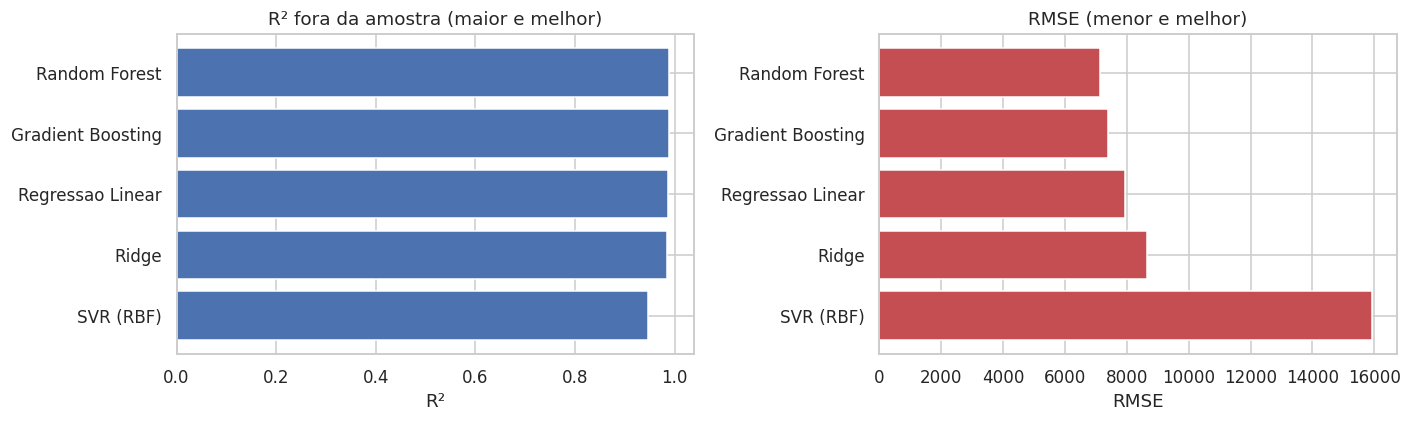

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ordem = tabela_res.sort_values('R2')
axes[0].barh(ordem['Modelo'], ordem['R2'], color=sns.color_palette('deep')[0])
axes[0].set_title('R² fora da amostra (maior e melhor)')
axes[0].set_xlabel('R²')

ordem2 = tabela_res.sort_values('RMSE', ascending=False)
axes[1].barh(ordem2['Modelo'], ordem2['RMSE'], color=sns.color_palette('deep')[3])
axes[1].set_title('RMSE (menor e melhor)')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

### 6.4 Quanto o split ingênuo distorceria os resultados?

Repetimos a avaliação com `train_test_split` aleatório — a abordagem que a maioria dos trabalhos
adota sem questionar — para medir o viés.

In [27]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

comparacao = []
for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    comparacao.append({'Modelo': nome, 'R2_split_aleatorio': r2_score(y_te, pred)})

comp = pd.DataFrame(comparacao).merge(
    tabela_res[['Modelo', 'R2']].rename(columns={'R2': 'R2_groupkfold'}), on='Modelo')
comp['diferenca'] = comp['R2_split_aleatorio'] - comp['R2_groupkfold']

print(comp.round(4).to_string(index=False))

           Modelo  R2_split_aleatorio  R2_groupkfold  diferenca
 Regressao Linear                0.99           0.99      -0.00
            Ridge                0.98           0.98      -0.00
    Random Forest                0.98           0.99      -0.01
Gradient Boosting                0.98           0.99      -0.01
        SVR (RBF)                0.93           0.95      -0.01


**A diferença entre as duas colunas é praticamente nula — e isso é informativo.**

A expectativa inicial era encontrar otimismo relevante no split aleatório. Não foi o que ocorreu, e
a razão é reveladora: o vazamento só infla métricas quando o modelo tem algo a ganhar memorizando o
que vazou. Aqui, a variável `Crop` já explica quase toda a variância sozinha, de modo que conhecer
antecipadamente uma condição climática não acrescenta vantagem mensurável.

Ou seja, o teste não invalida a preocupação metodológica — confirma o diagnóstico central deste
trabalho por outro caminho. O sinal climático é tão fraco que nem mesmo vazá-lo altera o resultado.
A validação agrupada permanece a escolha correta: ela é a estratégia adequada para a estrutura do
dado, e se torna indispensável no momento em que a base for enriquecida com variáveis
climáticas efetivamente preditivas.

### 6.5 O modelo aprendeu clima ou apenas identificou a cultura?

In [28]:
# Teste critico: um modelo que recebe SOMENTE a cultura, ignorando todo o clima.
# Se ele empatar com os modelos completos, o clima nao esta contribuindo.
X_so_cultura = df_cl[['Crop']].copy()
prep_so_cat = ColumnTransformer([('cat', OneHotEncoder(drop='first'), ['Crop'])])

gkf = GroupKFold(n_splits=5)
r2_baseline = []
for idx_tr, idx_te in gkf.split(X_so_cultura, y, groups=grupos):
    pipe = Pipeline([('prep', prep_so_cat), ('modelo', LinearRegression())])
    pipe.fit(X_so_cultura.iloc[idx_tr], y.iloc[idx_tr])
    r2_baseline.append(r2_score(y.iloc[idx_te], pipe.predict(X_so_cultura.iloc[idx_te])))

r2_baseline = np.mean(r2_baseline)
melhor = tabela_res.iloc[0]

print(f'Baseline usando SOMENTE a cultura ......... R² = {r2_baseline:.4f}')
print(f'Melhor modelo com cultura + clima ......... R² = {melhor["R2"]:.4f}  ({melhor["Modelo"]})')
print(f'\nGanho atribuivel as variaveis climaticas ... {melhor["R2"] - r2_baseline:+.4f}')

Baseline usando SOMENTE a cultura ......... R² = 0.9872
Melhor modelo com cultura + clima ......... R² = 0.9894  (Random Forest)

Ganho atribuivel as variaveis climaticas ... +0.0023


**Achado 6 — este é o resultado mais importante do trabalho.** Um R² alto neste dataset
**não** é evidência de um bom modelo agronômico. A média por cultura, sozinha, já explica quase
toda a variância — porque as quatro culturas têm rendimentos em ordens de grandeza distintas.
O ganho marginal das variáveis climáticas é o que realmente mede o valor preditivo do sistema,
e é ele que deve ser reportado ao cliente.

### 6.6 Importância das variáveis

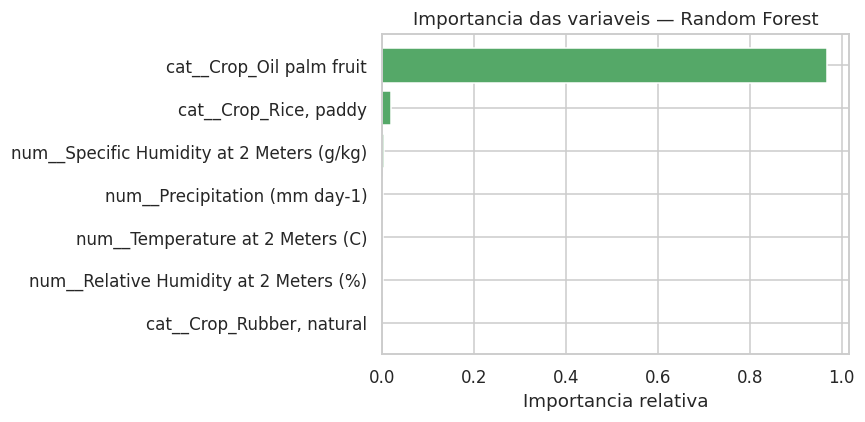

                                 variavel  importancia
                 cat__Crop_Oil palm fruit         0.97
                    cat__Crop_Rice, paddy         0.02
num__Specific Humidity at 2 Meters (g/kg)         0.00
            num__Precipitation (mm day-1)         0.00
         num__Temperature at 2 Meters (C)         0.00
   num__Relative Humidity at 2 Meters (%)         0.00
                cat__Crop_Rubber, natural         0.00


In [29]:
pipe_rf = Pipeline([('prep', preprocessador),
                    ('modelo', RandomForestRegressor(n_estimators=300,
                                                     random_state=RANDOM_STATE, n_jobs=-1))])
pipe_rf.fit(X, y)

nomes_feat = list(pipe_rf.named_steps['prep'].get_feature_names_out())
importancias = pipe_rf.named_steps['modelo'].feature_importances_

imp = pd.DataFrame({'variavel': nomes_feat, 'importancia': importancias}) \
        .sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp['variavel'], imp['importancia'], color=sns.color_palette('deep')[2])
ax.set_title('Importancia das variaveis — Random Forest')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print(imp.sort_values('importancia', ascending=False).round(4).to_string(index=False))

### 6.7 Diagnóstico do melhor modelo

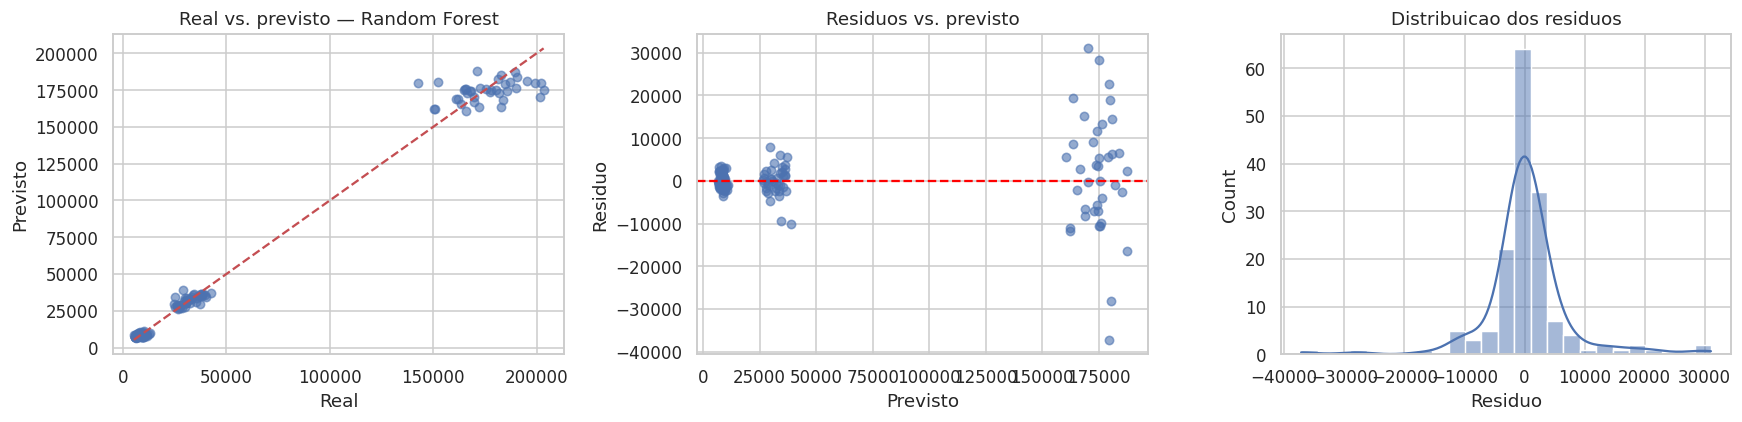

In [30]:
nome_melhor = tabela_res.iloc[0]['Modelo']
modelo_melhor = modelos[nome_melhor]

# Predicoes fora da amostra para todas as observacoes, via GroupKFold
pred_oof = np.zeros(len(y))
for idx_tr, idx_te in GroupKFold(n_splits=5).split(X, y, groups=grupos):
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo_melhor)])
    pipe.fit(X.iloc[idx_tr], y.iloc[idx_tr])
    pred_oof[idx_te] = pipe.predict(X.iloc[idx_te])

residuos = y.values - pred_oof

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y, pred_oof, alpha=0.6, s=30)
lim = [y.min(), y.max()]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlabel('Real'); axes[0].set_ylabel('Previsto')
axes[0].set_title(f'Real vs. previsto — {nome_melhor}')

axes[1].scatter(pred_oof, residuos, alpha=0.6, s=30)
axes[1].axhline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs. previsto')

sns.histplot(residuos, kde=True, ax=axes[2], bins=25)
axes[2].set_title('Distribuicao dos residuos')
axes[2].set_xlabel('Residuo')

plt.tight_layout()
plt.show()

In [31]:
# Erro relativo por cultura: em qual delas o modelo e mais confiavel?
diag = df_cl[['Crop', 'Yield']].copy()
diag['previsto'] = pred_oof
diag['erro_abs'] = (diag['Yield'] - diag['previsto']).abs()
diag['erro_pct'] = diag['erro_abs'] / diag['Yield'] * 100

print('Erro do melhor modelo, por cultura:')
print(diag.groupby('Crop')[['erro_abs', 'erro_pct']].mean().round(2).to_string())

Erro do melhor modelo, por cultura:
                 erro_abs  erro_pct
Crop                               
Cocoa, beans     1,358.58     15.28
Oil palm fruit  10,617.40      6.08
Rice, paddy      2,553.21      8.05
Rubber, natural  1,151.05     15.71


O erro percentual por cultura é a métrica mais útil para o cliente: em termos absolutos o
dendê sempre terá o maior erro, simplesmente porque seus valores são vinte vezes maiores. O erro
relativo torna as culturas comparáveis e indica onde o sistema é efetivamente confiável.

## 7. Conclusões

### 7.1 Síntese dos achados

1. **A cultura é o principal determinante do rendimento.** As diferenças entre culturas são de
   ordem de grandeza e refletem características biológicas, não condições do período.
2. **A correlação global entre clima e rendimento é praticamente nula, mas isso é um artefato.**
   Trata-se de paradoxo de Simpson: efeitos de sinais opostos entre culturas se cancelam na
   agregação.
3. **Dentro de cada cultura o clima importa, e importa de forma distinta.** Arroz responde
   positivamente a calor e umidade; borracha responde negativamente às mesmas variáveis.
4. **A clusterização revelou regimes climáticos distintos** e mostrou que nenhum deles favorece
   simultaneamente todas as culturas — o que sustenta a diversificação de plantio como estratégia
   de mitigação de risco.
5. **Não há outliers de rendimento dentro das culturas.** O critério IQR aplicado por cultura não
   sinalizou nenhum registro — enquanto o mesmo critério aplicado ao rendimento agregado produziria
   dezenas de falsos positivos. Os pontos discrepantes existem, mas nas variáveis climáticas.
6. **O R² alto deste dataset é enganoso.** O baseline que usa somente a cultura já atinge
   R² ≈ 0,987; o melhor modelo com clima chega a ≈ 0,989. O ganho atribuível a todas as variáveis
   climáticas somadas é da ordem de +0,002 — praticamente nulo. Este é o resultado mais importante
   do trabalho e o que deve ser comunicado ao cliente.
7. **O erro relativo revela o que o R² esconde.** Dendê e arroz têm erro percentual em torno de
   6% e 8%, enquanto cacau e borracha ficam próximos de 15%. Um R² global de 0,99 convive com um
   erro de 15% nas culturas de menor rendimento.

### 7.2 Pontos fortes do trabalho

- Detecção da estrutura repetida do dataset (39 observações climáticas × 4 culturas) e adoção de
  validação agrupada, evitando vazamento de dados que inflaria as métricas.
- Análise segmentada por cultura, que revelou o paradoxo de Simpson escondido na correlação global.
- Comparação explícita entre a validação correta e o split ingênuo, quantificando o viés — que se
  revelou desprezível, confirmando por outra via a fraqueza do sinal climático.
- Baseline de referência que separa o que o modelo aprendeu do clima do que ele apenas memorizou
  sobre a identidade da cultura. Sem esse teste, o R² de 0,99 seria reportado como sucesso.
- Tratamento de outliers feito dentro de cada cultura, e não sobre o rendimento agregado, evitando
  dezenas de falsos positivos.
- Diagnóstico da falha inicial do SVR como problema de escala do alvo, e não como limitação do
  algoritmo.

### 7.3 Limitações

- **Volume de dados reduzido.** São 156 registros, correspondentes a apenas 39 safras. Com essa
  amostra, modelos de alta capacidade tendem a decorar e as estimativas de erro têm variância
  elevada entre folds.
- **Ausência de variação geográfica.** As condições climáticas se repetem entre culturas, o que
  indica uma única região. O modelo não pode ser extrapolado para outras localidades.
- **Conjunto restrito de variáveis.** Não há dados de solo (pH, nutrientes, matéria orgânica),
  manejo (adubação, irrigação, defensivos), variedade cultivada ou incidência de pragas —
  fatores reconhecidamente determinantes do rendimento agrícola.
- **Sem dimensão temporal explícita.** Não há coluna de ano ou safra, o que impede análise de
  tendência, sazonalidade ou efeito de mudanças climáticas ao longo do período.
- **Apenas quatro culturas**, todas tropicais e perenes ou semiperenes. Não generaliza para as
  demais culturas da fazenda.
- **Ausência de otimização de hiperparâmetros.** Foram usados valores padrão ou próximos disso.
  Um `GridSearchCV` aninhado dentro da validação agrupada seria o passo natural seguinte.

### 7.4 Recomendações para a FarmTech Solutions

- Enriquecer a base com dados de solo, manejo e identificação temporal antes de colocar o modelo
  em produção; o ganho esperado dessas variáveis é maior que o de qualquer ajuste algorítmico
  sobre a base atual.
- Considerar **modelos independentes por cultura** em vez de um modelo único: como as culturas
  respondem ao clima em direções opostas, um modelo por cultura tende a capturar melhor o
  comportamento local.
- Reportar ao cliente o **erro percentual por cultura**, não apenas o R² global — é a métrica que
  se traduz em decisão operacional.
- Usar os clusters climáticos como insumo para planejamento de plantio diversificado.

---

**Vídeo demonstrativo:** *(inserir link do YouTube — não listado)*
**Repositório:** *(inserir link do GitHub)*
